# Project: Investigate a Dataset - Medical Appointment No Shows

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 
This dataset contains information about 11,0527 medical apppointments booked in Brazil. This was collected via the public Kaggle dataset "Medical Appointment No Shows" (Originally sourced from the Brazilian Public Health System). Each row in the dataset represents a single medical appointment, and the columns provide various details about the appointment.

Columns:
1. PatientId, AppointmentID -- identifiers
2. AppointmentID -- unique identifier for each appointment
3. Gender, Age -- patient demographics
4. ScheduledDay -- the date and time the appointment was booked
5. AppointmentDay -- the date of the appointment itself
6. Age -- the age of the patient
7. Neighbourhood -- where the appointment took place
8. Scholarship -- whether the patient is enrolled in Brazil's Bolsa Familia welfare program
9. Hipertension, 
10. Diabetes, 
11. Alcoholism, 
12. Handcap -- health condition flags (Handcap is a 0-4 severity scale, not binary)
13. SMS_received -- whether a reminder SMS was sent before the appointment
14. No-show -- the target variable: "Yes" means the patient did NOT show up


### Question(s) for Analysis
This analysis investigates three specific, answerable questions rather than an open-ended "what predicts no-shows":

1. Does the lead time between scheduling and the appointment date relate to the no-show rate, and does that relationship differ between patients who received an SMS reminder and those who didn't?
2. Do chronic health conditions (Hipertension, Diabetes) and patient Age relate to no-show rate, and if so, is that explained by some other factor they're correlated with (such as lead time), or does it look independent?
3. Does Handicap severity (the 0-4 scale) show a graded, dose-response relationship with no-show rate, or is any apparent pattern likely just noise?

Each question is explored at both the single-variable (1D) level and in combination with other variables (2D/3D), with relevant summary statistics computed alongside each visualization.

In [245]:
# Use this cell to set up import statements for all of the packages that you
#   plan to use.

# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.dpi'] = 100
%matplotlib inline


<a id='wrangling'></a>
## Data Wrangling

> **Tip**: In this section of the report, you will load in the data, check for cleanliness, and then trim and clean your dataset for analysis. Make sure that you **document your data cleaning steps in mark-down cells precisely and justify your cleaning decisions.**


### General Properties
> **Tip**: You should _not_ perform too many operations in each cell. Create cells freely to explore your data. One option that you can take with this project is to do a lot of explorations initially. This does not have to be organized, but make sure you use enough comments to understand the purpose of each code cell. Then, after you're done with your analysis, trim the excess and organize your steps so that you have a flowing, cohesive report.

In [246]:
# Load your data and print out a few lines. What is the size of your dataframe? 
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.
df = pd.read_csv("KaggleV2-May-2016.csv")
print("Shape", df.shape)
df.head(3)

Shape (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No


In [247]:
df.info

<bound method DataFrame.info of            PatientId  AppointmentID Gender          ScheduledDay  \
0       2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1       5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2       4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3       8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4       8.841186e+12        5642494      F  2016-04-29T16:07:23Z   
...              ...            ...    ...                   ...   
110522  2.572134e+12        5651768      F  2016-05-03T09:15:35Z   
110523  3.596266e+12        5650093      F  2016-05-03T07:27:33Z   
110524  1.557663e+13        5630692      F  2016-04-27T16:03:52Z   
110525  9.213493e+13        5630323      F  2016-04-27T15:09:23Z   
110526  3.775115e+14        5629448      F  2016-04-27T13:30:56Z   

              AppointmentDay  Age      Neighbourhood  Scholarship  \
0       2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0   
1       2016-

In [ ]:
# check for missing values in every column
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

No missing values in any column -- that simplifies the cleaning step. Since there is no need to decide on an imputation or removal strategy for missing values, we can focus on other aspects of data cleaning such as data types, outliers, and consistency.

In [251]:
# check for duplicate appointment recodes
print("Duplicated AppointmentID rows: ", df['AppointmentID'].duplicated().sum())
print("Unique PatientId: ", df['PatientId'].nunique(), "/ Total Rows: ", len(df))

Duplicated AppointmentID rows:  0
Unique PatientId:  62299 / Total Rows:  110527


No duplicate AppointmentID values, Patients appearing multiple times is expecgted and not data quality issue - this simply means many patients booked more than one appointment over the period covered by this dataset. 

Checking for the Invalid Values in columns that otherwise look clean by dtype - the kind of issue df.inof() and .isnull() would not catch. For example, a negative Age is a non-null value, but it is not a valid age.

In [256]:
# Age should be never be negative. check the full range, not just describe(),
# since a single outlier can be hidden inside a percentile summary
print("Age min/max: ", df['Age'].min(), df['Age'].max())
print("Rows with Age < 0: ", (df['Age'] <0).sum())

print("Row Index with Age < 0:")
df.loc[df['Age'] < 0]

Age min/max:  -1 115
Rows with Age < 0:  1
Row Index with Age < 0:


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


In [257]:
print("Row with Age == 115: ")
df.loc[df['Age'] == 115]

Row with Age == 115: 


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
63912,3.196321e+13,5700278,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
63915,3.196321e+13,5700279,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
68127,3.196321e+13,5562812,F,2016-04-08T14:29:17Z,2016-05-16T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
76284,3.196321e+13,5744037,F,2016-05-30T09:44:51Z,2016-05-30T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,No
97666,7.482346e+14,5717451,F,2016-05-19T07:57:56Z,2016-06-03T00:00:00Z,115,SÃO JOSÉ,0,1,0,0,0,1,No


There is exactly one patient index (988832) with Age -1, which is not a valid age and certainly is a data entry error. This will be dropped from the dataset during cleaning below.
For only one row out of 110,527, dropping it costs essentially nothing in terms of data loss. If the Age -1 count as 5% of the dataset, it would have been imputed with the mean or median value of the Age column. However, since it is less than 5% of the dataset, it will be dropped from the dataset.

The maximum age 115 looks extreme but it is not a one-off: the value 115 appears multiple times for a single patient and one time for another patient. This is a valid age and more consistent, so it will be kept in the dataset.

In [258]:
df.dtypes

PatientId         float64
AppointmentID       int64
Gender                str
ScheduledDay          str
AppointmentDay        str
Age                 int64
Neighbourhood         str
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show               str
dtype: object

In [259]:
# Dates are currently strings.
# since the time-of-day components matters

df[['ScheduledDay', 'AppointmentDay']].head(3)

,ScheduledDay,AppointmentDay
0,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z
1,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z
2,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z


Every `AppointmentDate` value ends in T00:00:00Z - midnight UTC. This worth more checking for the entire column. If this is true for all values, it means the time portion of the `AppointmentDay` is not a real data, but just an artifact of how the data was collected and stored. Treating with a real time stamp will curropt the data analysis.

In [ ]:
sched_at = pd.to_datetime(df['ScheduledDay'])
appt_at = pd.to_datetime(df['AppointmentDay'])

# confirm AppointmentDay truly has no time-of-day information in any row
print("AppointmentDay times that are Not midnight:", (
    appt_at.dt.time != pd.Timestamp('00:00:00').time()).sum()
)

# full-datetime comparison would flag same-day appointments as 'date_invalid
# because midnight (00:00:00) is earlier in the day than whatever time the 
# appointment was scheduled at.
naive_invalid = (sched_at > appt_at).sum()
print("Naive datetime-level 'invalid' count (WRONG check): ", naive_invalid)

# since the time component of the AppointmentDay is not meaningful
# the way forward is to compare the DATES only
date_invalid = (sched_at.dt.date > appt_at.dt.date).sum()
print("Correct date_level invalid count: ", date_invalid)

AppointmentDay times that are Not midnight: 0
Naive datetime-level 'invalid' count (WRONG check):  38568
Correct date_level invalid count:  5


Comparing with full-datetime falsely flags 38,568 rows (about 35% of the dataset) as having imposible schedule, when in fact they are just same-day appointments where the time portion of the `AppointmentDay` could be an artificial or prefill value of midnight. Comparing with date-only values, reduces to 5 rows that are genuinely impossible (scheduled after the appointment date), which is a much more reasonable number of data entry errors. These 5 rows will be dropped from the dataset during cleaning below and compute a meaningful "lead-time" feature later.

Inspecting the 5 rows directly before dropping them

In [270]:
lead_days_check = (appt_at.dt.date - sched_at.dt.date).apply(lambda d: d.days)
df.loc[lead_days_check < 0, ['ScheduledDay', 'AppointmentDay', 'No-show']] 

,ScheduledDay,AppointmentDay,No-show
27033,2016-05-10T10:51:53Z,2016-05-09T00:00:00Z,Yes
55226,2016-05-18T14:50:41Z,2016-05-17T00:00:00Z,Yes
64175,2016-05-05T13:43:58Z,2016-05-04T00:00:00Z,Yes
71533,2016-05-11T13:49:20Z,2016-05-05T00:00:00Z,Yes
72362,2016-05-04T06:50:57Z,2016-05-03T00:00:00Z,Yes


All 5 rows are also marked `No-show = Yes`. 5 rows is a small sample to draw any statistical conclusions from, but it is a suggestive pattern that these data entry errors may be more likely to occur in no-show appointments, perhaps because the appointment was cancelled after scheduling but the cancellation was not properly recorded in the dataset. This is just speculation, but it is a reminder of how data quality issues can introduce bias into an analysis if not properly handled. These 5 rows will be dropped from the dataset during cleaning below.

Checking the binary flags if they are actually binary (0/1), sice they will be treated as boolean variables in the analysis.

In [272]:
binary_cols = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']

for col in binary_cols:
    print(f"{col}: {sorted(df[col].unique())}")
print(f"Handicap: {sorted(df['Handcap'].unique())}")

Scholarship: [np.int64(0), np.int64(1)]
Hipertension: [np.int64(0), np.int64(1)]
Diabetes: [np.int64(0), np.int64(1)]
Alcoholism: [np.int64(0), np.int64(1)]
SMS_received: [np.int64(0), np.int64(1)]
Handicap: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


All five binary flags (Scholarship, Hipertension, Diabetes, Alcoholism, SMS_received) are cleanly binary with only 0 and 1 values. The Handcap column is not binary but has integer values from 0 to 4, which is consistent with the documentation that it is a severity scale rather than a simple yes/no flag. This will be treated as ordinal variable later rather than grouped in with the the binary flags.

In [273]:
print(df['Handcap'].value_counts().sort_index())

Handcap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64


Statistics of the Numerical columns

In [109]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
desc = df[numeric_cols].describe().T
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
desc['zeros_pct'] = (df[numeric_cols] == 0).mean() * 100
desc['negative_pct'] = (df[numeric_cols] < 0).mean() * 100
print(desc)

                  count                  mean                    std  \
PatientId      110527.0  147496265710394.0625  256094920291739.09375   
AppointmentID  110527.0        5675305.123427            71295.75154   
Age            110527.0             37.088874              23.110205   
Scholarship    110527.0              0.098266               0.297675   
Hipertension   110527.0              0.197246               0.397921   
Diabetes       110527.0              0.071865               0.258265   
Alcoholism     110527.0                0.0304               0.171686   
Handcap        110527.0              0.022248               0.161543   
SMS_received   110527.0              0.321026               0.466873   

                       min              25%               50%  \
PatientId      39217.84439  4172614444192.0  31731838713978.0   
AppointmentID    5030230.0        5640285.5         5680573.0   
Age                   -1.0             18.0              37.0   
Scholarship        

Statistics of the Categorical columns

In [110]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print("Top 5 values:")
    print(df[col].value_counts(dropna=False).head())
    print("Cardinality ratio:", round(df[col].nunique() / len(df), 4))


--- Gender ---
Unique values: 2
Top 5 values:
Gender
F    71840
M    38687
Name: count, dtype: int64[pyarrow]
Cardinality ratio: 0.0

--- ScheduledDay ---
Unique values: 103549
Top 5 values:
ScheduledDay
2016-05-06T07:09:54Z    24
2016-05-06T07:09:53Z    23
2016-04-25T17:18:27Z    22
2016-04-25T17:17:46Z    22
2016-04-25T17:17:23Z    19
Name: count, dtype: int64[pyarrow]
Cardinality ratio: 0.9369

--- AppointmentDay ---
Unique values: 27
Top 5 values:
AppointmentDay
2016-06-06T00:00:00Z    4692
2016-05-16T00:00:00Z    4613
2016-05-09T00:00:00Z    4520
2016-05-30T00:00:00Z    4514
2016-06-08T00:00:00Z    4479
Name: count, dtype: int64[pyarrow]
Cardinality ratio: 0.0002

--- Neighbourhood ---
Unique values: 81
Top 5 values:
Neighbourhood
JARDIM CAMBURI     7717
MARIA ORTIZ        5805
RESISTÊNCIA        4431
JARDIM DA PENHA    3877
ITARARÉ            3514
Name: count, dtype: int64[pyarrow]
Cardinality ratio: 0.0007

--- No-show ---
Unique values: 2
Top 5 values:
No-show
No     88208
Yes

Correlations stats

In [112]:
numeric_cols_for_corr = [c for c in numeric_cols if c not in ["PatientId", "AppointmentID"]]
print(df[numeric_cols_for_corr].corr().round(3))

                Age  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  \
Age           1.000       -0.092         0.505     0.292       0.096    0.078   
Scholarship  -0.092        1.000        -0.020    -0.025       0.035   -0.009   
Hipertension  0.505       -0.020         1.000     0.433       0.088    0.080   
Diabetes      0.292       -0.025         0.433     1.000       0.018    0.058   
Alcoholism    0.096        0.035         0.088     0.018       1.000    0.005   
Handcap       0.078       -0.009         0.080     0.058       0.005    1.000   
SMS_received  0.013        0.001        -0.006    -0.015      -0.026   -0.024   

              SMS_received  
Age                  0.013  
Scholarship          0.001  
Hipertension        -0.006  
Diabetes            -0.015  
Alcoholism          -0.026  
Handcap             -0.024  
SMS_received         1.000  


In [118]:
print(df['No-show'].value_counts(normalize=True))

No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: double[pyarrow]



### Data Cleaning

Summary of the data cleaning steps applied below and the reasoning behind each step:
1. Parse dates first: Both `ScheduledDay` and `AppointmentDay` are currently stored as strings. They will be parsed into datetime objects to enable date-based calculations such as lead time between scheduling and appointment.
2. Drop the one row with Age < 0, before any dtype narrowing. This order matters: an earlier exploration of this dataset found that casting Age to an unsigned 8-bit integer type before removing the invalid -1 value causes it to silently wrap around to 255 (integer underflow) instead of raising an error - a dangerous, silent corruption that would have gone unnoticed without manually checking the row. Filtering on the original invalid value (-1) rather than the wrapped value (255) is also more robust: a filter that only catches 255 is fixing this specific symptom, not the underlying problem, and wouldn't catch a different out-of-range value (e.g. -5) if the data changes in the future.
3. Drop the 5 rows with impossible schedule (AppointmentDay before ScheduledDay). These are likely data entry errors and will be dropped to avoid corrupting the lead day calculations and any analysis involving scheduling patterns.
4. Create a new "LeadDays" column that computes the number of days between scheduling and appointment. This is a more meaningful feature for analysis than the raw datetime columns, and it will be used in the analysis of how lead days relates to no-show rates.
5. Narrow dtypes last, and use pandas' nullable unsigned integer type ('UInt8', capitalized) rather than NumPy's plain 'uint8'. As an extra safeguard on top of cleaning the data first, the nullable type raises a clear error on an unsafe/out-of-range cast instead of silently wrapping - so even if an invalid value were missed above, this step would fail loudly rather than corrupt the data quietly.

In [277]:
# After discussing the structure of the data and any problems that need to be
#   cleaned, perform those cleaning steps in the second part of this section.

def drop_invalid_rows(data, mask, reason):
    """
    Drop rows matching a boolean mask of invalid records, and
    display how many rows were removed and why.

    Args:
        data: pd.DataFrame
        mask: od.Series of bool - True marks rows to Drop
        reason: str - short description of why these rows are being removed

    Returns:
        pd.DataFrame with the matching rows removed
    """
    n_dropped = int(mask.sum())
    cleaned = data.loc[~mask].copy()
    print(f"Dropped {n_dropped} row(s): {reason}")
    return cleaned



In [280]:
def display_steps(message: str):
    """
    Display message

    Args:
        message: str - Information to display

    Return: 
        message
    """
    return print(message)

In [283]:
# Step 1: parse dates
display_steps("Step 1: parse date")

df_an = df.copy()
df_an['AppointmentDay'] = pd.to_datetime(df_an['AppointmentDay'])
df_an['ScheduledDay'] = pd.to_datetime(df_an['ScheduledDay'])

Step 1: parse date


In [284]:
# Step 2: drop invalid Age, Before any dtype narrowing
display_steps("Step 2: drop invalid Age")

age_mask = df_an['Age'] < 0
df_an = drop_invalid_rows(
    df_an,
    age_mask,
    "Age < 0 (data entry error, no valid imputation target)"
)

Step 2: drop invalid Age
Dropped 1 row(s): Age < 0 (data entry error, no valid imputation target)


In [286]:
# Step 3: drop date-level invalid schedules
display_steps("Step 3: drop date-level invalid schedules")

lead_days_temp = (
    df_an['AppointmentDay'].dt.date - df_an['ScheduledDay'].dt.date).apply(lambda d: d.days)
date_mask = lead_days_temp < 0
df_an = drop_invalid_rows(
    df_an,
    date_mask,
    "AppointmentDay date before ScheduledDay date (impossible)"
)

Step 3: drop date-level invalid schedules
Dropped 0 row(s): AppointmentDay date before ScheduledDay date (impossible)


In [289]:
# Step 4: Compute LeadDays on the now-clean data
display_steps("Step 4: Compute LeadDays on the now-clean data")

df_an['LeadDays'] = lead_days_temp.loc[df_an.index]

print("Shape before cleaning: ", df.shape)
print("Shape after cleaning: ", df_an.shape)

Step 4: Compute LeadDays on the now-clean data
Shape before cleaning:  (110527, 14)
Shape after cleaning:  (110521, 15)


In [293]:
# Step 5: narrow dtypes after invalid values have been removed
display_steps("Step 5: narrow dtypes after invalid values have been removed")
# Using pandas nullable 'UInt8' (capital), not NumPy's lowercase 'uint8',
# because the nullable type raises on an unsafe cast rather than wrapping.

binary_and_ordinal_cols = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']
for col in binary_and_ordinal_cols:
    df_an[col] = df_an[col].astype('UInt8')

df_an['Age'] = df_an['Age'].astype('UInt8')
df_an['PatientId'] = df_an['PatientId'].astype('int64')

# A boolean version of the target is convinient for arithmetic (.mean())
df_an['NoShowBool'] = (df_an['No-show'] == 'Yes')

print("Age range after cleaning: ", df_an['Age'].min(), "-", df_an['Age'].max())
df_an.dtypes

Step 5: narrow dtypes after invalid values have been removed
Age range after cleaning:  0 - 115


PatientId                       int64
AppointmentID                   int64
Gender                            str
ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
Age                             UInt8
Neighbourhood                     str
Scholarship                     UInt8
Hipertension                    UInt8
Diabetes                        UInt8
Alcoholism                      UInt8
Handcap                         UInt8
SMS_received                    UInt8
No-show                           str
LeadDays                        int64
NoShowBool                       bool
dtype: object

Memory usage of the dataset before and after changing the data types of the columns to save memory.

In [292]:
before_conversion = df.memory_usage(index=True, deep=True).sum()  / (1024**2)
after_conversion = df_an.memory_usage(index=True, deep=True).sum() / (1024**2)
print(
    f"Before: {before_conversion:.2f}MB",
    f"\nAfter: {after_conversion:.2f}MB"
    )
print(f"Reduction: {(1 - after_conversion/before_conversion) * 100:.1f}%")

Before: 17.58MB 
After: 10.76MB
Reduction: 38.8%


Cleaning is completed!

The New dataset has 110,521 rows (6 fewer than the original 110,527: 1 row with Age < 0 and 5 rows with impossible schedule were dropped) no missing values, no duplicates, correctly-typed columns, a new "LeadDays" column and NoShowBool column that will be used in the analysis below.

<a id='eda'></a>
## Exploratory Data Analysis


### Research Question 1: Lead Time and SMS Reminder

In [307]:
def label_axes(ax, title, xlabel, ylabel):
    """
    Apply a consistent title and axis labels

    Args:
        ax: ax
        title: str - Title of the plot
        xlabel: str - x axis label
        ylabel: str - y axis label

    Return: ax
    """
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    return ax

def rate_with_n(data, group_col, target_col='NoShowBool'):
    """
    Group by group_col and return the no-show rate and group size

    Args:
        data: pd.DataFrame
        group_col: pd series (columns)
        target_Col: pd series (columns)

    Return:
        Group by n
    """
    return data.groupby(
        group_col,
        observed=True)[target_col].agg(
            no_show_rate='mean',
            n='count'
        )

# overall no-show rate, for reference throught the rest of this section
overall_rate = df_an['NoShowBool'].mean()
print(f"Overall no-show rate: {overall_rate:.1%}")

Overall no-show rate: 20.2%


Question 1: Lead Time and SMS reminder

1D: distribution of lead time

In [308]:
print(df_an['LeadDays'].describe())

count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: LeadDays, dtype: float64


Lead time ranges from 0 (same day) to 179 days, with a median of just 4 days. 
This distribution is highly right-skewed, with a long tail of appointments scheduled far in advance. The majority of appointments are scheduled weeks or months in advance of the appointment date, which may have implications for patient attendance and no-show rates.

2D: no-show rate by lead time

Lead time is bucketed using pd.cut (a vectorized operation, no loops) into groups that reflect meaningfully different scheduling situations, from same day to over a month in advance.

In [310]:
bins = [-1, 0, 1, 3, 7, 14, 30, 1000]
bucket_labels = ['Same day', '1 day', '2-3 days', '4-7 days', '8-14 days', '15-30 days', '30+ days']
df_an['LeadBucket'] = pd.cut(df_an['LeadDays'], bins=bins, labels=bucket_labels)

lead_rates = rate_with_n(df_an, 'LeadBucket')
print(lead_rates)

            no_show_rate      n
LeadBucket                     
Same day        0.046471  38562
1 day           0.213505   5213
2-3 days        0.237371   9462
4-7 days        0.252027  17510
8-14 days       0.304699  12025
15-30 days      0.325888  17371
30+ days        0.330025  10378


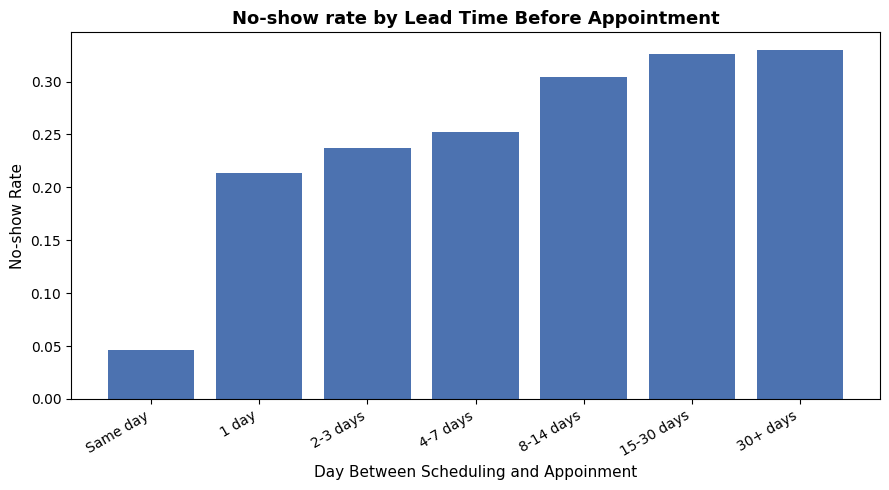

In [318]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(lead_rates.index.astype(str), lead_rates['no_show_rate'], color='#4C72B0')
label_axes(ax, 'No-show rate by Lead Time Before Appointment',
           'Day Between Scheduling and Appoinment', 'No-show Rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

There's a clear, fairly monotonic relationship between lead time and no-show rate, with longer lead times generally associated with higher no-show rates. The no-show rate is lowest for same-day appointments (LeadDays = 0) at around 4.6%, and it increases steadily with lead time, reaching around 33% for appointments scheduled over a month in advance (LeadDays > 30). This pattern suggests that patients may be more likely to change plan or priorioties the longer the gap between scheduling and the appointment date. The increase in no-show rate is particularly steep for the first few weeks of lead time, indicating that the risk of no-shows rises quickly as the appointment date gets further away.

**3-variable view: does an SMS reminder change the pattern, and does the relationship between depend on lead time?**

In [321]:
# SMS_received
cross_tab = pd.crosstab(df_an['SMS_received'], df_an['NoShowBool'])
chi2, p, dof, expected = stats.chi2_contingency(cross_tab)
print(cross_tab)

print(f"\n Chi-square test: chi2={chi2:.2f}, p={p:.4g}")

print("\n Marginal no-show rate by SMS_received:")
print(df_an.groupby('SMS_received')['NoShowBool'].mean())

NoShowBool    False  True 
SMS_received              
0             62509  12530
1             25698   9784

 Chi-square test: chi2=1767.98, p=0

 Marginal no-show rate by SMS_received:
SMS_received
0    0.166980
1    0.275745
Name: NoShowBool, dtype: float64


Those who received SMS reminders show a **high no-show-rate** (27%) than those who didn't (16%). The Chi-Square test confirms this is not due to change (p < 0.0001). This is a surprising finding, as one might expect that receiving an SMS reminder would decrease the no-show rate. However, it is possible that patients who are more likely to no-show are also more likely to receive SMS reminders (e.g. because they have a history of no-shows), which could explain this association. To further investigate this, we can look at the relationship between lead time and no-show rate separately for those who received SMS reminders and those who didn't.

Third variable view: Lead time and SMS reminder

In [323]:
pivot = df_an.groupby(
    ['LeadBucket', 'SMS_received'],
    observed=True)['NoShowBool'].mean().unstack()
print(pivot)

SMS_received         0         1
LeadBucket                      
Same day      0.046471       NaN
1 day         0.213505       NaN
2-3 days      0.239949  0.213024
4-7 days      0.271112  0.239711
8-14 days     0.337582  0.281125
15-30 days    0.368705  0.298004
30+ days      0.375252  0.302028


NaN above means that bucket has (near) zero rows for that SMS group -
e.g. almost nobody gets an SMS reminder for a same-day appointment, since
there's no lead time to send one. This is real, not a bug.

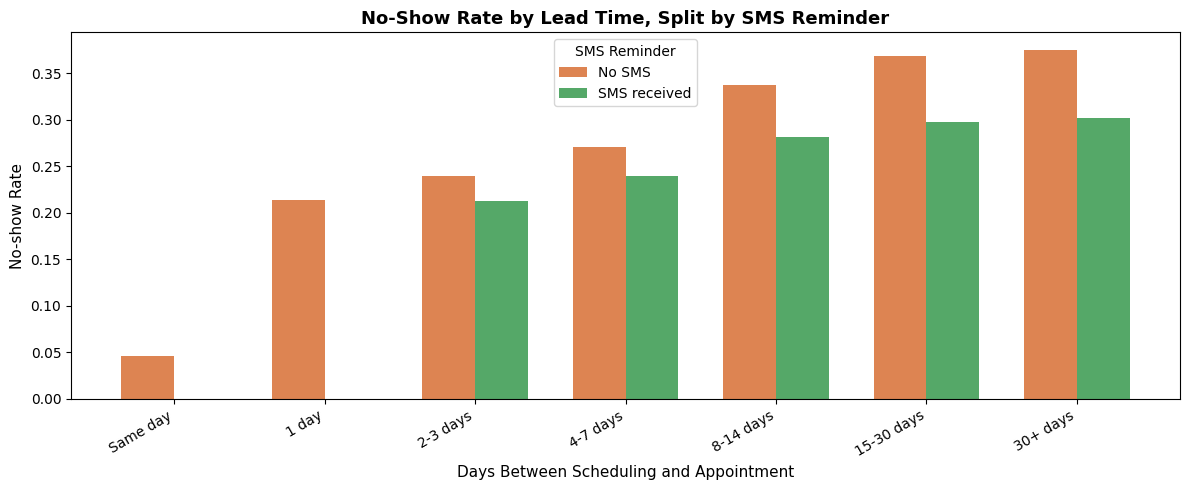

In [339]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(pivot.index))
width = 0.35
ax.bar(x - width/2, pivot[0], width, label='No SMS', color='#DD8452')
ax.bar(x + width/2, pivot[1], width, label='SMS received', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index.astype(str), rotation=30, ha='right')
label_axes(ax, 'No-Show Rate by Lead Time, Split by SMS Reminder',
           'Days Between Scheduling and Appointment',
           'No-show Rate'
        )
ax.legend(title='SMS Reminder')
plt.tight_layout()

This is an example of the Simpson's paradox: the marginal (unstratified) comparison is misleading because SMS_received is confounded with lead time. Same-day and next-day appointments are almost entirely in the "No SMS" group (It does not make sense to send a reminder on before a same-day visit), and this group has the lowest no-show rate of all, which drag the overall "No SMS" average down.

Once lead time is held roughly constant by looking within each bucket, the pattern reverses: in every bucket where both groups have meaningful data, patients who received an SMS reminder show lower no-show rate than those who didn't. For example, in the 15-30 day bucket: 29.8% with SMS vs 36.9% without. This satisfy the intuitive expectation that reminders help. However, it does not prove that SMS reminder cause the lower no-show rates. 

### Research Question 2: Age and Chronic Conditions

In [352]:
age_bins = [-1, 12, 18, 35, 50, 65, 120]
age_labels = ['0-12', '13-18', '19-35', '36-50', '51-65', '66+']
df_an['AgeBucket'] = pd.cut(df_an['Age'].astype(int), bins=age_bins, labels=age_labels)

age_rates = rate_with_n(df_an, 'AgeBucket')
print(age_rates)

           no_show_rate      n
AgeBucket                     
0-12           0.204706  21035
13-18          0.260536   7830
19-35          0.238285  24135
36-50          0.203222  22099
51-65          0.165491  22122
66+            0.155263  13300


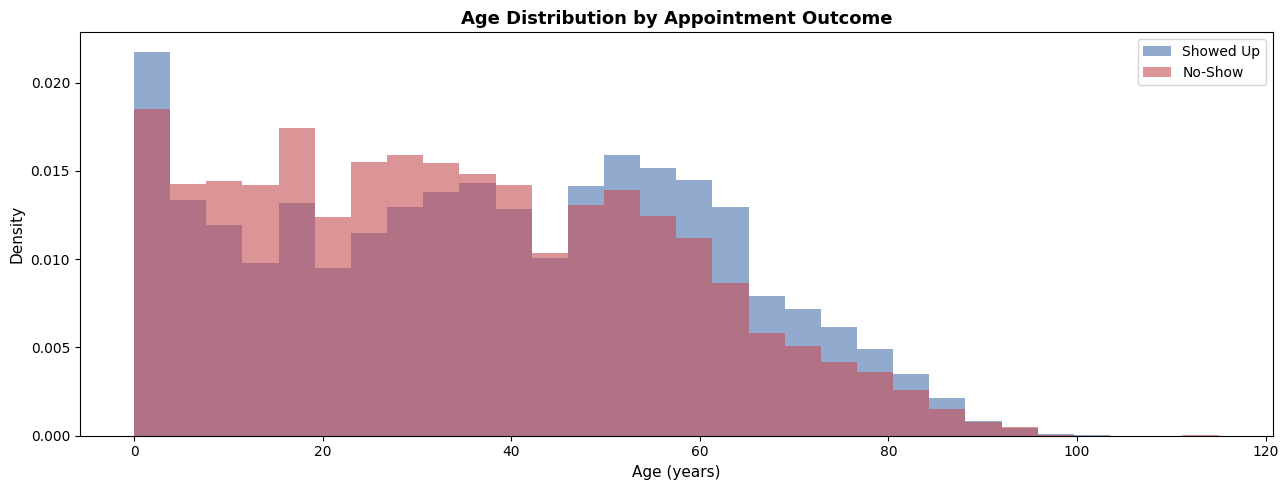

In [355]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))

# No Show up
ax.hist(
    df_an.loc[~df_an['NoShowBool'],
              'Age'].astype(float), 
              bins=30, alpha=0.6, label='Showed Up',
              color='#4C72B0', density=True
)

# Showed up
ax.hist(
    df_an.loc[df_an['NoShowBool'],
              'Age'].astype(float),
              bins=30, alpha=0.6, label='No-Show',
              color='#C44E52', density=True
)

label_axes(ax, 'Age Distribution by Appointment Outcome',
           'Age (years)', 'Density'
)

ax.legend()
plt.tight_layout()
plt.show()

No-Show rate is not monotonic with age. No-Show rate it's actually the highest amongst teenagers and young adults (13-18: ~26%, 19-35: ~24%) and lowest among older adults (66+: ~16%). Children (0-12) sit in the middle at ~20%. Younger adults have less predictable shcedules and possibly less perceived urgency than older patients managing chronic conditions - reasonable hypothesis worht looking into.

2D: Chronic conditions vs no-show

In [356]:
for cond in ['Hipertension', 'Diabetes']:
    rate = df_an.groupby(cond)['NoShowBool'].mean()
    cross_tab = pd.crosstab(df_an[cond], df_an['NoShowBool'])
    chi2, p, dof, exp = stats.chi2_contingency(cross_tab)
    print(f"--- {cond} ---")
    print(rate)
    print(f"chi2={chi2:.2f}, p={p:.4g}")
    print()

--- Hipertension ---
Hipertension
0    0.208995
1    0.173020
Name: NoShowBool, dtype: float64
chi2=140.34, p=2.246e-32

--- Diabetes ---
Diabetes
0    0.203591
1    0.180033
Name: NoShowBool, dtype: float64
chi2=25.25, p=5.045e-07



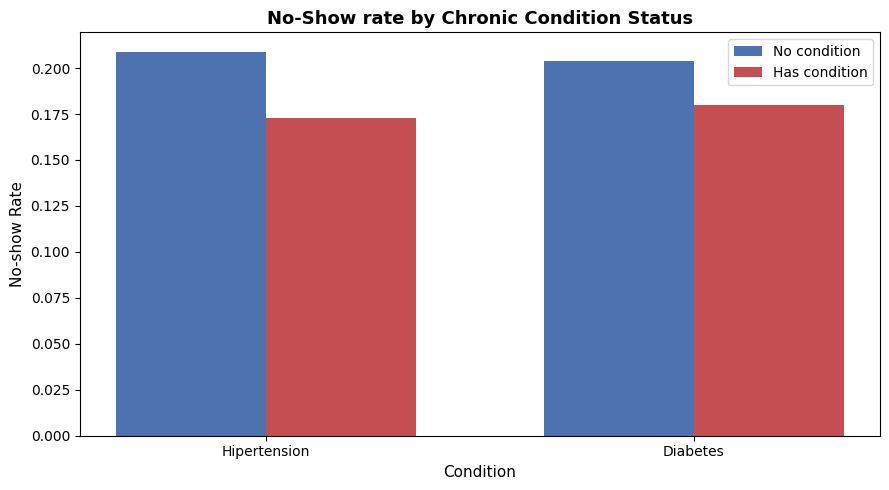

In [362]:
fig, ax = plt.subplots(figsize=(9, 5))
conditions = ['Hipertension', 'Diabetes']
rate_0 = [df_an.loc[df_an[c] == 0, 'NoShowBool'].mean() for c in conditions]
rate_1 = [df_an.loc[df_an[c] == 1, 'NoShowBool'].mean() for c in conditions]
x = np.arange(len(conditions))
width = 0.35
ax.bar(x - width/2, rate_0, width, label='No condition', color='#4C72B0')
ax.bar(x + width/2, rate_1, width, label='Has condition', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
label_axes(ax,
           'No-Show rate by Chronic Condition Status',
           'Condition', 'No-show Rate'
        )
ax.legend()
plt.tight_layout()
plt.show()

Hipertension and Diabetes are associated with a lower no-show rate.

Hipertension ~17.3% and Diabetes ~18.0% vs ~20-21% for patients wihtout conditions, and both differences are statistically significant by ch2-square test. 

Since these two conditions are naturally more common with age and age itself relates to no-show rate as shown above. The question is whether this is really a condition effect or a reflection of age.

Check whether the conditions effect could instead be explained by Lead Time or by Age

In [367]:
display_steps("Mean LeadDays, by Hipertension status:")
print(f"{df_an.groupby('Hipertension')['LeadDays'].mean()}\n")

display_steps("Mean Age, by Hipertension status:")
print(df_an.groupby('Hipertension')['Age'].mean())

Mean LeadDays, by Hipertension status:
Hipertension
0    10.314687
1     9.653915
Name: LeadDays, dtype: float64

Mean Age, by Hipertension status:
Hipertension
0    31.308826
1    60.613596
Name: Age, dtype: Float64


Lead Time is nearly identical between the two groups (9.65 vs 1.31 days). So Lead Time is not the explanation here. 

Age, however differs drastically. Patients with Hipertension average age 61 years old compare to 31.3 years old without. Given that older patients were already shown to have noticeable lower no-show rate, the Hipertension effect looks much more likely to be a reflection of the age between these two groups than effect on medical condition itself.

Further proving can be done with Logistic Regression. 

Research Question 3: Handicap severity

1D/2D: no-show rate at each severity

In [369]:
handicap_rates = rate_with_n(df_an, 'Handcap')
print(handicap_rates)

         no_show_rate       n
Handcap                      
0            0.202333  108282
1            0.178431    2040
2            0.202186     183
3            0.230769      13
4            0.333333       3


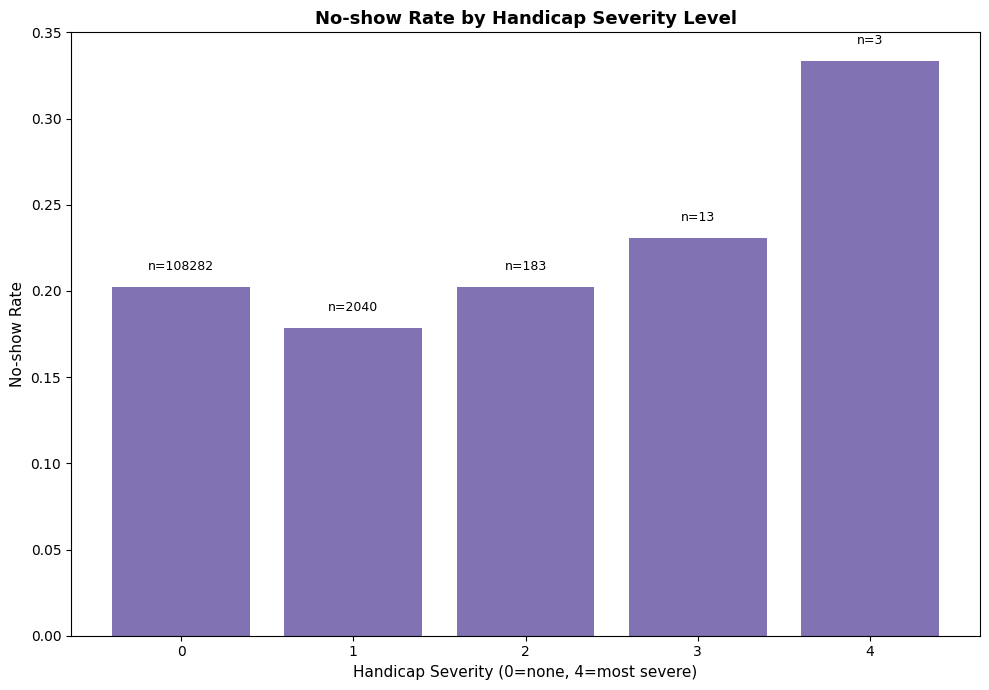

In [372]:
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(
    handicap_rates.index.astype(str),
    handicap_rates['no_show_rate'], color='#8172B3')
for i, (rate, n) in enumerate(
    zip(handicap_rates['no_show_rate'], handicap_rates['n'])):
    ax.text(i, rate + 0.01, f'n={n}', ha='center', fontsize=9)
label_axes(ax,
           'No-show Rate by Handicap Severity Level',
           'Handicap Severity (0=none, 4=most severe)',
           'No-show Rate'
        )
plt.tight_layout()
plt.show()


Level 0 through 2 are essentially flat, all siting around 18-20%, showing no meaningful trend as severity increases from none to moderate.
Level 3 and 4 show a higher rates around 23% and 33%, which could be a trend or start of trend, but the sample size 13 and 3 are too tiny. Thus, these two bars cannot be a relaible evidence and should not be taken as a real effect.

No usable pattern detected!

<a id='conclusions'></a>
## Conclusions

Question 1 (Lead time and SMS reminder)
Lead time has a strong, fairly monotonic relationship with no-show rate. Same-day appointments are missed only about 5% of the time, rising to roughly a third of appointments booked more than a month out. Looking at SMS reminder without accounting for lead time gives a misleading answer. It appears reminders are associated with more no-shows, purely because reminder-eligible appointments are concentrated among longer-lead-time bookings, which have a higher baseline no-show rate regardless of the reminder. Once lead time is held roughly constant, SMS reminders are associated with a lower no-show rate in every bucket with adequate data - consistent with the intuitive expectation, but only visible once the confound was idenitified and controlled for.

Question 2 (age and chronic conditions): No-show rate is highest among teenagers and young adults and lowest among older patients. Hipertension and Diabetes are both associated with lower no-show rates, but this does not appear to be an independent effect of the conditions themselves -- patients with Hipertension are, on average, twice the age of those without it, and age alone already predicts a similar pattern. Lead time, an earlier candidate explanation, was checked and ruled out (it's nearly identical between groups). Age looks like the more fundamental factor, though confirming this precisely would need a model that controls for age directly, rather than the descriptive group comparisons used here.


Question 3 (Handicap severity): No usable dose-response relationship was found. The first three severity levels are flat, and the two highest levels have far too few records (13 and 3 respectively) to estimate a reliable rate. This is a case where the honest conclusion is "the data can't support an answer to this question," rather than reporting noisy percentages as if they were meaningful.

**Limitations**

- All relationships reported here are correlational, not causal. None of the variables examinded (SMS reminders, chronic conditions, age, lead time) were randomly assigned, so any of them could be confoudned by unmeasured factors. the clearest example encountered directly in this analysis was the Simpson's paradox on the SMS/lead -time relationships: a marginal comparison gave an answer that reversed oncea third variable was introduced, which is a strong reminder that an association observed between any two variables here could still be hiding a similar lurking variable that hasn't been checked.
- Small subgroups produces unrelaible rate estimates. Handicap severity levels 3 and 4 (n=13, and n=3) are the clearest example, but the same cautions applies to any other subgroupd analysis not explicitly checked for sample size in this notebook.
- The dataset is limited to an SMS was sent, not whether other reminder types (phone calls, email, etc) were used, so "no SMS" is not the same as "no reminder of any kind" which could understate the true difference reminders make.
- AppointmentDay has no real time-of-day information (every value is midnight), so lead time could only be computed at day-level granularity. If apppointment time-of-day were available, afine-grained lead time (e.g in hours) might have reveal patterns invisible at the day level.
- Further research directions: a logistic regression model controlling for age, lead time, SMS status simultaneously would help separate the overlapping effect identified in Question 2 in a way that simple group comparisons cannot. It would also be useful to know which neighbourhood or clinics have access to SMS reminder systems, since that itself be a confound for the SMS relationship found above. 

In [373]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

/home/isah-idris/Documents/GitHub/AI-Infrastructure/Practice/Generative_AI/Multimodal_AI/vision/vision/.venv/bin/python: No module named nbconvert
